In [2]:
from importlib import reload
import sys
import subprocess

import scipy
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../python")
import pymodelica
reload(pymodelica)


<module 'pymodelica' from '/mnt/c/Users/Tom/Documents/ThermalModel/python/pymodelica.py'>

# Run the simualtion

In [11]:
MODEL_NAME = "System_LMO_exe"
MODEL_FILE = "../System_LMO.mo"
MODEL_FILE_LIN = "../build/linearized_model.py"
EQUILIBRIUM_TIME = 20.0
# PARAMS = "../parameters/params_lmo_v1_mod_tes.txt"
PARAMS = "../parameters/params_lmo_v1_mod_absorber.txt"
# PARAMS = "../parameters/params_lmo_v1_default.txt"
# PARAMS = "../parameters/params.txt"


# Step 1. a fast simulation to reach equilibrium


In [ ]:
log = subprocess.run(
    [
        f"./{MODEL_NAME}",
        # "-lv=-LOG_STDOUT",
        f"-overrideFile={PARAMS}",
        "-startTime=0",
        f"-stopTime={EQUILIBRIUM_TIME}",
        "-stepSize=2e-4",
        "-tolerance=1e-8",
        "-s=dassl",
        "-w", # Show all warnings
        "-outputFormat=mat",
        f"-r={MODEL_NAME}_res_init.mat", # Result filename
        f"-l={EQUILIBRIUM_TIME}", ## Perform linearization
    ],
    cwd="../build",
    check=True,
    capture_output=True, text=True
)
log.stderr, log.stdout


('',
 'LOG_STDOUT        | warning | You are overriding Bias_C with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding Bias_L with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding Edep_time with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding K4 with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding K7 with a small value or zero.\n|                 | |       |

In [14]:
# Plot all C and G to check if the system is at equilibrium

filename_init = f'../build/{MODEL_NAME}_res_init.mat'
time_steps_init, data_init = pymodelica.load_om_mat(filename_init)

pymodelica.mod_svg("../System_LMO.svg", "temp_image.svg", data_init, system_name="System_LMO", width=1500, display=True)

## Step 1b. Noise and Complex impedance

In [ ]:
reload(pymodelica)

<module 'pymodelica' from '/mnt/c/Users/Tom/Documents/ThermalModel/python/pymodelica.py'>

In [ ]:
MODEL_FILE = "../System_LMO.mo"
MODEL_FILE_LIN = "../build/linearized_model.py"

filename_steady_state = f'../build/{MODEL_NAME}_res_init.mat'
time_steps, simulation_results = pymodelica.load(filename_steady_state)

model = pymodelica.TESModel(MODEL_FILE_LIN, 
                 MODEL_FILE, 
                 simulation_results = simulation_results,
                 config={"L": 0.3e-6, "RL": 0.02}, 
                 f_min = 1, f_max = 100e3, points = 1000)

In [ ]:
noise_current, frequencies = model.get_noise(RL_temperature = 0.2,
    noise_electronics = 3.2e-12,
    noise_flicker_corner = 20,
    noise_flicker_gamma = 1,
    index_cinput = -1)

Resolution (Sigma) in eV =  (5663.3050196234+5272.5627656034385j)


Readout noise 6.334754453646691e-11
External Johnson noise 6.102066268863493e-12
TES Johnson noise 3.82153182224763e-12
TFN_1 2.907574749237502e-13
TFN_4 4.1821206270430706e-12
TFN_7 3.899909331471809e-12
TFN_8 7.959962729731195e-13
TFN_14 1.3333780892683473e-13


Text(0, 0.5, 'Current noise [A/sqrtHz]')

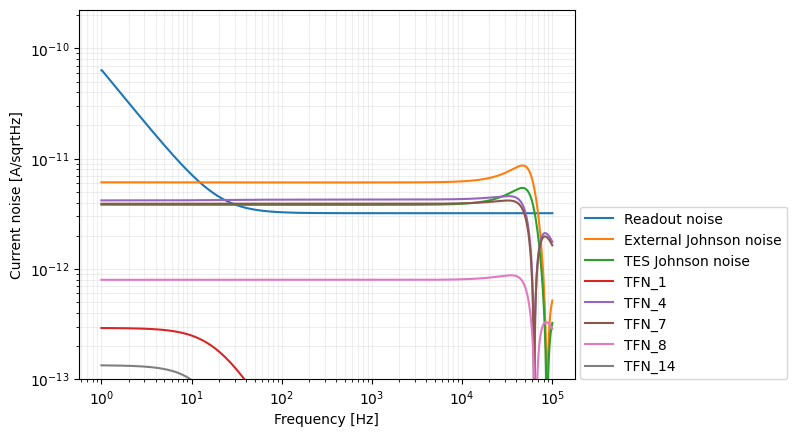

In [235]:
lower_lim = 1e-13
for key in noise_current:
    noise = abs(noise_current[key])
    if noise[0]<lower_lim:
        continue
    plt.loglog(frequencies, noise, label=key)
    print(key, noise[0])
plt.legend(loc=(1.01,0))
plt.ylim(lower_lim,)
plt.grid(which="both", alpha=0.2)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Current noise [A/sqrtHz]")

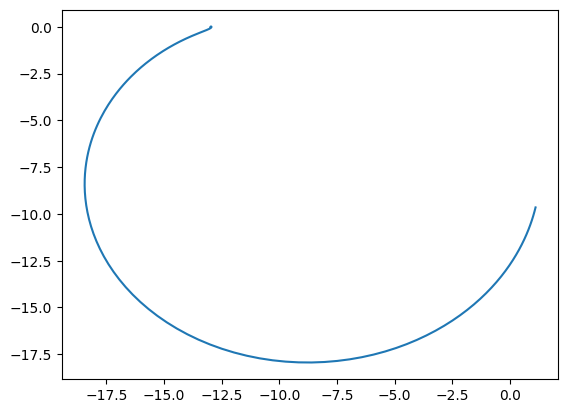

In [ ]:
dIdV = model.get_dIdV()
plt.plot(dIdV.real, dIdV.imag)

# Step 2: impulse response

Compile another simulation with fine resolution starting from the final values of Step 1

In [ ]:

# Using -iif (Import Initial File) and -iit (Import Initial Time) to reset startTime = 0.0
log2 = subprocess.run(
    [
        f"./{MODEL_NAME}",
        f"-r={MODEL_NAME}_res_final.mat",
        f"-overrideFile={PARAMS}",
        "-s=dassl",
        "-w",
        "-startTime=0",
        "-stopTime=0.1",
        "-stepSize=1e-6",
        "-tolerance=1e-8",
        f"-iif={MODEL_NAME}_res_init.mat",
        f"-iit={EQUILIBRIUM_TIME}",
        "-lv=-LOG_STDOUT",
    ],
    cwd="../build",
    check=True,
    capture_output=True, text=True
)
log2.stderr, log2.stdout

('',
 'LOG_STDOUT        | warning | You are overriding Bias_C with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding Bias_L with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding Edep_time with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding K4 with a small value or zero.\n|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.\nLOG_STDOUT        | warning | You are overriding K7 with a small value or zero.\n|                 | |       |

In [ ]:
filename = f'../build/{MODEL_NAME}_res_final.mat'

time_steps, data = pymodelica.load(filename)
print(data.keys())

dict_keys(['CL.v', 'L.i', 'c1.T', 'c10.T', 'c2.T', 'c3.T', 'c4.T', 'c5.T', 'c6.T', 'c7.T', 'c8.T', 'c9.T', 'der(CL.v)', 'der(L.i)', 'der(c1.T)', 'der(c10.T)', 'der(c2.T)', 'der(c3.T)', 'der(c4.T)', 'der(c5.T)', 'der(c6.T)', 'der(c7.T)', 'der(c8.T)', 'der(c9.T)', 'C1', 'C10', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'CL.i', 'G1', 'G10', 'G11', 'G12', 'G13', 'G14', 'G2', 'G3', 'G4', 'G5', 'G6', 'G7', 'G8', 'G9', 'GND.p.i', 'GND.p.v', 'HeatSource.port.Q_flow', 'HeatSource1.port.Q_flow', 'L.v', 'RL.LossPower', 'RL.R_actual', 'RL.i', 'c1.P_Joule', 'c1.R', 'c1.cp', 'c1.heatPort.Q_flow', 'c1.v', 'c10.cp', 'c10.port.Q_flow', 'c2.cp', 'c2.port.Q_flow', 'c3.cp', 'c3.port.Q_flow', 'c4.cp', 'c4.port.Q_flow', 'c5.cp', 'c5.port.Q_flow', 'c6.cp', 'c6.port.Q_flow', 'c7.cp', 'c7.port.Q_flow', 'c8.cp', 'c8.port.Q_flow', 'c9.cp', 'c9.port.Q_flow', 'edep_film.y', 'edep_target.y', 'fixedTemperature.port.Q_flow', 'g1.Q_flow', 'g10.Q_flow', 'g11.Q_flow', 'g12.Q_flow', 'g13.Q_flow', 'g14.Q_flow', 'g2.Q

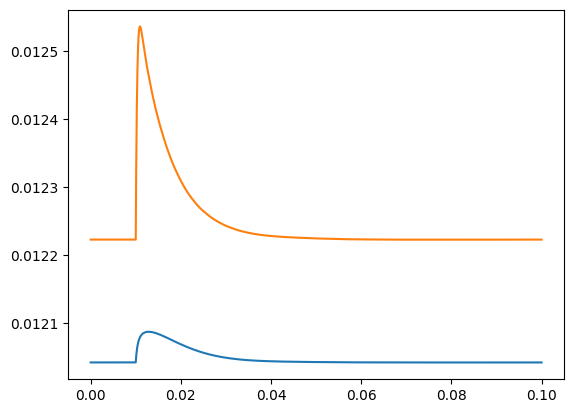

In [ ]:
# plt.plot(time_steps, data['tes.i'])
plt.plot(time_steps, data['T1'])
plt.plot(time_steps, data['T2'])
# plt.plot(time_steps, data['T10'])